--- Starting SARIMA (Seasonal ARIMA) Consumption Forecasting ---
--- With Population and Income Growth as Exogenous Variables ---

Exogenous variables created:
Population growth range: 0.000230 to 0.000350
Income growth range: -0.045615 to 0.045955
--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -0.3964
p-value: 0.9107
Critical Values:
   1%: -3.4861
   5%: -2.8859
   10%: -2.5798
Conclusion: The series is NOT stationary (p > 0.05).

Training period: 2015-01-01 00:00:00 to 2021-12-01 00:00:00
Test period: 2022-01-01 00:00:00 to 2024-12-01 00:00:00
Exogenous variables shape: (132, 2)

Fitting SARIMA model with exogenous variables...


c:\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                           HCLQTCON   No. Observations:                   84
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -769.451
Date:                            Mon, 03 Aug 2026   AIC                           1552.901
Time:                                    16:28:11   BIC                           1568.838
Sample:                                01-01-2015   HQIC                          1559.246
                                     - 12-01-2021                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
pop_growth    -1.664e+08      3.414  -4.87e+07      0.000   -1.66e+08   -1.66e+08
income_gro

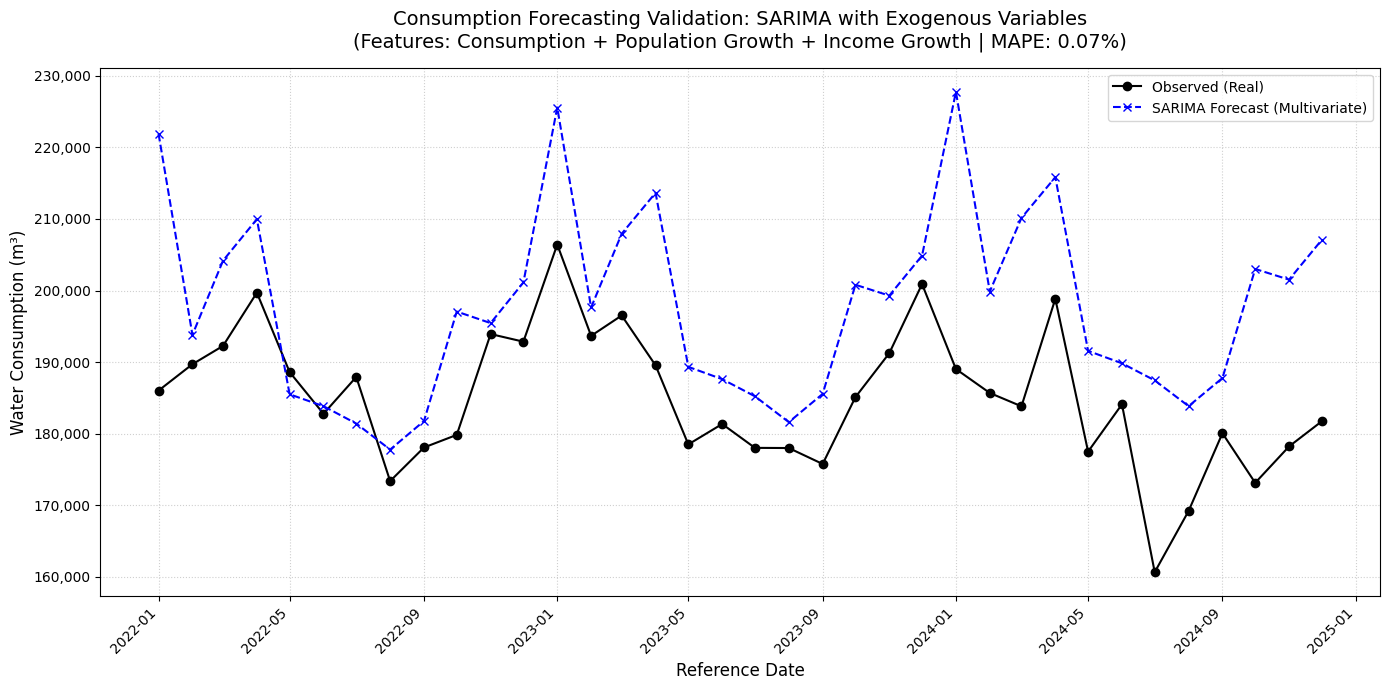


--- Exogenous Variable Coefficients ---
pop_growth: coefficient = -166406727.911373, p-value = 0.0000
income_growth: coefficient = -26696.282070, p-value = 0.3275


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_percentage_error as mape

# ==========================================
# 1. Configuration and Paths
# ==========================================
BASE_PATH = '..'
INPUT_FILE = os.path.join(BASE_PATH, 'includes', 'dados','Tabela_consumo_Itapua_120m.csv')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-sarima-forecast-validation-multi.pdf'

# ==========================================
# 1.1 Growth Rates Vectors (2016-2025)
# ==========================================
taxas_crescimento_mensal = [
    0.00034,  # 2016
    0.00034,  # 2017
    0.00035,  # 2018
    0.00034,  # 2019
    0.00032,  # 2020
    0.00030,  # 2021
    0.00029,  # 2022
    0.00027,  # 2023
    0.00025,  # 2024
    0.00023   # 2025
]

percentuais_aumento_renda = [
    -0.040694617,  # 2016
    0.005083616,   # 2017
    0.005261762,   # 2018
    0.009585339,   # 2019
    -0.045615004,  # 2020
    0.039183815,   # 2021
    0.021387542,   # 2022
    0.004332235,   # 2023
    0.045954924,   # 2024
    0.011194       # 2025
]

def test_stationarity(series):
    """
    Performs the Augmented Dickey-Fuller (ADF) test to check for stationarity.
    """
    result = adfuller(series.dropna())
    print('--- Augmented Dickey-Fuller (ADF) Test ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print("Conclusion: The series is stationary (p <= 0.05).")
    else:
        print("Conclusion: The series is NOT stationary (p > 0.05).")

def create_exog_variables(dates, pop_rates, inc_rates):
    """
    Creates exogenous variables for SARIMA model.
    Returns DataFrame with population_growth and income_growth aligned with dates.
    """
    # Create monthly series for population and income growth rates
    pop_growth_monthly = []
    inc_growth_monthly = []
    
    # Get year from dates
    years = dates.year
    unique_years = sorted(years.unique())
    
    for year in unique_years:
        year_idx = year - 2016  # 2016 is index 0
        if 0 <= year_idx < len(pop_rates):
            pop_rate = pop_rates[year_idx]
            inc_rate = inc_rates[year_idx]
        else:
            # For years outside the range (like 2015 or beyond 2025), use the closest available
            if year < 2016:
                pop_rate = pop_rates[0]
                inc_rate = inc_rates[0]
            else:
                pop_rate = pop_rates[-1]
                inc_rate = inc_rates[-1]
        
        # Add 12 months of rates for this year
        pop_growth_monthly.extend([pop_rate] * 12)
        inc_growth_monthly.extend([inc_rate] * 12)
    
    # Trim to match the exact number of dates
    pop_growth_monthly = pop_growth_monthly[:len(dates)]
    inc_growth_monthly = inc_growth_monthly[:len(dates)]
    
    return pd.DataFrame({
        'pop_growth': pop_growth_monthly,
        'income_growth': inc_growth_monthly
    }, index=dates)

def main():
    print("--- Starting SARIMA (Seasonal ARIMA) Consumption Forecasting ---")
    print("--- With Population and Income Growth as Exogenous Variables ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    if not os.path.exists(INPUT_FILE):
        print(f"Error: Input file not found at {INPUT_FILE}")
        return

    df = pd.read_csv(INPUT_FILE, sep=';')
    df['AM_REFERENCIA'] = pd.to_datetime(df['AM_REFERENCIA'], format='%Y%m')
    
    # Aggregation and Sorting
    df_aggregated = df.groupby('AM_REFERENCIA')['HCLQTCON'].sum().reset_index()
    df_aggregated = df_aggregated.sort_values(by='AM_REFERENCIA')
    ts = df_aggregated.set_index('AM_REFERENCIA')['HCLQTCON']

    # ==========================================
    # 3. Create Exogenous Variables
    # ==========================================
    exog = create_exog_variables(
        ts.index,
        taxas_crescimento_mensal,
        percentuais_aumento_renda
    )
    
    print("\nExogenous variables created:")
    print(f"Population growth range: {exog['pop_growth'].min():.6f} to {exog['pop_growth'].max():.6f}")
    print(f"Income growth range: {exog['income_growth'].min():.6f} to {exog['income_growth'].max():.6f}")

    # Stationarity Check
    test_stationarity(ts)

    # ==========================================
    # 4. Train-Test Split (Chronological)
    # ==========================================
    train_mask = ts.index <= pd.to_datetime('2021-12-31')
    test_mask = (ts.index >= pd.to_datetime('2022-01-01')) & (ts.index <= pd.to_datetime('2024-12-31'))
    
    train = ts[train_mask]
    test = ts[test_mask]
    exog_train = exog[train_mask]
    exog_test = exog[test_mask]
    
    print(f"\nTraining period: {train.index.min()} to {train.index.max()}")
    print(f"Test period: {test.index.min()} to {test.index.max()}")
    print(f"Exogenous variables shape: {exog.shape}")

    # ==========================================
    # 5. SARIMA Modeling with Exogenous Variables
    # ==========================================
    # Parameters (p,d,q) x (P,D,Q,s)
    # Note: s=12 for monthly data with annual seasonality
    print("\nFitting SARIMA model with exogenous variables...")
    model = SARIMAX(
        train, 
        exog=exog_train,
        order=(1, 0, 1), 
        seasonal_order=(1, 1, 1, 12)
    )
    model_fit = model.fit(disp=False)
    
    print("\nModel Summary:")
    print(model_fit.summary())

    # Forecasting with exogenous variables
    predictions = model_fit.predict(
        start=len(train), 
        end=len(train)+len(test)-1, 
        exog=exog_test,
        dynamic=False
    )
    predictions.index = test.index

    # Metrics
    mape_value = mape(test, predictions)
    print(f'\nValidation MAPE: {mape_value:.2f}%')

    # Comparison Table
    comparison_df = pd.DataFrame({
        'Observed': test,
        'Predicted': predictions
    })
    print("\nComparison Results (Test Window):")
    print(comparison_df)

    # ==========================================
    # 6. Visualization and Export
    # ==========================================
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(test.index, test, label='Observed (Real)', color='black', marker='o', linestyle='-')
    ax.plot(predictions.index, predictions, label='SARIMA Forecast (Multivariate)', color='blue', marker='x', linestyle='--')

    ax.set_title(f"Consumption Forecasting Validation: SARIMA with Exogenous Variables\n"
                 f"(Features: Consumption + Population Growth + Income Growth | MAPE: {mape_value:.2f}%)", 
                 fontsize=14, pad=15)
    ax.set_ylabel('Water Consumption (m³)', fontsize=12)
    ax.set_xlabel('Reference Date', fontsize=12)
    
    # Format Y axis with thousands separator
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()

    # Save to PDF for LaTeX integration
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"\nSuccess! SARIMA validation chart saved at: {save_path}")
    plt.show()

    # ==========================================
    # 7. Feature Importance Analysis
    # ==========================================
    print("\n--- Exogenous Variable Coefficients ---")
    if hasattr(model_fit, 'params'):
        param_names = model_fit.params.index
        for name in param_names:
            if 'pop_growth' in name or 'income_growth' in name:
                coef = model_fit.params[name]
                pval = model_fit.pvalues[name] if name in model_fit.pvalues.index else None
                print(f"{name}: coefficient = {coef:.6f}, p-value = {pval:.4f}")

if __name__ == "__main__":
    main()